# NLP701@MBZUAI Fall 2025 - Lab 02

## Today's Agenda
- Text processing practice
  - sentence segmentation
  - word tokenization
  - stemming and lemmatization
  - [Optional] compare the performance of a text classifier with lemmatization and without
- N-gram language model
  - Train your own model almost like ChatGPT
  - [Optional] compare your model with answers of ChatGPT from API.
 



(Note: If you're running this on your local machine, you need to install dependencies by running `pip install nltk matplotlib`.)

# **1. Text Processsing Practice: Sentence Segmentation, Tokenization, Stemming, and Lemmatization**

## Preparing Data
We are going to use titles and abstracts of papers published at [ACL2024](https://2024.aclweb.org/).
We first download the XML file from ACL's [GitHub repository](https://github.com/acl-org/acl-anthology).

![picture](https://2024.aclweb.org//assets/images/bangkok/bangkok-banner.jpeg)
ACL2024 took place in Bangkok from August 11-16, 2024.

In [1]:
!wget "https://raw.githubusercontent.com/acl-org/acl-anthology/master/data/xml/2024.acl.xml"
#!curl -O https://raw.githubusercontent.com/acl-org/acl-anthology/master/data/xml/2024.acl.xml
#!pip install lxml

--2026-03-28 06:27:40--  https://raw.githubusercontent.com/acl-org/acl-anthology/master/data/xml/2024.acl.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2202588 (2.1M) [text/plain]
Saving to: ‘2024.acl.xml.2’

2024.acl.xml.2      100%[===================>]   2.10M  --.-KB/s    in 0.06s   

2026-03-28 06:27:40 (35.7 MB/s) - ‘2024.acl.xml.2’ saved [2202588/2202588]



Here, we define a function that parses the XML file and extracts titles and abstracts.
We parse the XML file using [`BeautifulSoup`](https://www.crummy.com/software/BeautifulSoup/bs4/doc/).
For each paper, we create a dictionary with three keys: paper `id`, `title`, and `abstract`.

##### if required install the xml parser via (!pip install lxml)

In [2]:
%conda install bs4

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [3]:
from bs4 import BeautifulSoup

def extract_aclanthology(file_path) -> list:
    # read the xml file
    with open(file_path, 'r') as f:
        file = f.read()
    xml = BeautifulSoup(file, 'lxml')
    # extract only long and short papers
    volume = xml.find('volume', attrs={"id": ["long", "short"]})
    # extract paper id, title, and abstract
    # list of dictionary with three keys: id, title, and abstract
    papers = [{'id': t.get('id'),
              'title': t.title.text,
              'abstract': t.abstract.text}
              for t in volume.find_all('paper')]

    return papers

Now that we defined our function, we can extract abstracts and titles.

In [4]:
%conda install lxml

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [5]:
acl2024 = extract_aclanthology('./2024.acl.xml')
# extract only abstracts
acl2024_abstract = [paper['abstract'] for paper in acl2024]
acl2024_title = [paper['title'] for paper in acl2024]

/tmp/ipykernel_1966773/2503645518.py:7: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  xml = BeautifulSoup(file, 'lxml')


Let's look at an example.

In [6]:
acl2024_abstract[0]

'Finetuning large language models (LLMs) has been empirically effective on a variety of downstream tasks. Existing approaches to finetuning an LLM either focus on parameter-efficient finetuning, which only updates a small number of trainable parameters, or attempt to reduce the memory footprint during the training phase of the finetuning. Typically, the memory footprint during finetuning stems from three contributors: model weights, optimizer states, and intermediate activations. However, existing works still require considerable memory, and none can simultaneously mitigate the memory footprint of all three sources. In this paper, we present quantized side tuing (QST), which enables memory-efficient and fast finetuning of LLMs by operating through a dual-stage process. First, QST quantizes an LLM’s model weights into 4-bit to reduce the memory footprint of the LLM’s original weights. Second, QST introduces a side network separated from the LLM, which utilizes the hidden states of the L

## Preprocessing using NLTK

As we saw last week, we are going to use `nltk` library to further process this text.



In [7]:
%conda install nltk --y

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [8]:
## before running this cell, reload the kernel

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

# download necessary packages
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('punkt_tab')

# split each abstract paragraph into sentences
sentences = [sent_tokenize(p) for p in acl2024_abstract]

[nltk_data] Downloading package punkt to /home/khang.nhat/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/khang.nhat/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/khang.nhat/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/khang.nhat/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/khang.nhat/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Let's check out the output.

In [9]:
sentences[0]

['Finetuning large language models (LLMs) has been empirically effective on a variety of downstream tasks.',
 'Existing approaches to finetuning an LLM either focus on parameter-efficient finetuning, which only updates a small number of trainable parameters, or attempt to reduce the memory footprint during the training phase of the finetuning.',
 'Typically, the memory footprint during finetuning stems from three contributors: model weights, optimizer states, and intermediate activations.',
 'However, existing works still require considerable memory, and none can simultaneously mitigate the memory footprint of all three sources.',
 'In this paper, we present quantized side tuing (QST), which enables memory-efficient and fast finetuning of LLMs by operating through a dual-stage process.',
 'First, QST quantizes an LLM’s model weights into 4-bit to reduce the memory footprint of the LLM’s original weights.',
 'Second, QST introduces a side network separated from the LLM, which utilizes t

We can further tokenize each sentence into words.

Here, we are using nested list comprehension to loop over a list of a list.
If you're not familiar with nested list comprehension, check out this website:  https://www.geeksforgeeks.org/nested-list-comprehensions-in-python/

In [10]:
# split each sentence into a list of words
tokenized_abstract = [word_tokenize(s) for p in sentences for s in p]

Here's a sample sentence that is tokenized into words.

In [11]:
tokenized_abstract[0]

['Finetuning',
 'large',
 'language',
 'models',
 '(',
 'LLMs',
 ')',
 'has',
 'been',
 'empirically',
 'effective',
 'on',
 'a',
 'variety',
 'of',
 'downstream',
 'tasks',
 '.']

We can do the same thing for titles as well.

In [12]:
tokenized_title = [word_tokenize(s) for s in acl2024_title]
tokenized_title[0]

['Quantized',
 'Side',
 'Tuning',
 ':',
 'Fast',
 'and',
 'Memory-Efficient',
 'Tuning',
 'of',
 'Quantized',
 'Large',
 'Language',
 'Models']

## Normalizing Text

### Lowercasing
When we look at the titles, we observe that each word is capitalized.
To ignore the distinction between "A" and "a", we can use `lower()` to normalize the text to lowercase.

In [13]:
lower_title = [[word.lower() for word in title] for title in tokenized_title]

In [14]:
lower_title[0]

['quantized',
 'side',
 'tuning',
 ':',
 'fast',
 'and',
 'memory-efficient',
 'tuning',
 'of',
 'quantized',
 'large',
 'language',
 'models']

### Stemming
Often we want to go further than this, and strip off any affixes, a task known as stemming.
NLTK includes several off-the-shelf stemmers, and if you ever need a stemmer you should use one of these in preference to crafting your own using regular expressions, since these handle a wide range of irregular cases.

In [15]:
porter = nltk.PorterStemmer()

Here's an example of stemming for the word "going":

In [16]:
porter.stem('going')

'go'

We can then apply stemming to all the titles as follows.

In [17]:
stem_title = [[porter.stem(word) for word in title] for title in lower_title]

In [18]:
stem_title[0]

['quantiz',
 'side',
 'tune',
 ':',
 'fast',
 'and',
 'memory-effici',
 'tune',
 'of',
 'quantiz',
 'larg',
 'languag',
 'model']

### Lemmatization
A further step is to make sure that the resulting form is a known word in a dictionary, a task known as lemmatization.

The WordNet lemmatizer only removes affixes if the resulting word is in its dictionary.
This additional checking process makes the lemmatizer slower than the above stemmers. Notice that it doesn't handle lying, but it converts women to woman.

In [19]:
wnl = nltk.WordNetLemmatizer()

Here's an example for lemmatization for the word "dogs":

In [20]:
wnl.lemmatize('dogs')

'dog'

We can then lemmatize all the titles as follows.

In [21]:
lemma_title = [[wnl.lemmatize(word) for word in title] for title in lower_title]

In [22]:
lemma_title[0]

['quantized',
 'side',
 'tuning',
 ':',
 'fast',
 'and',
 'memory-efficient',
 'tuning',
 'of',
 'quantized',
 'large',
 'language',
 'model']

Now that we know how to normalize text, let's look at the trending words at ACL2024 by calculating simple statistics.

In [23]:
import itertools
import string

from nltk.corpus import stopwords
from nltk.probability import FreqDist

# define stop words
stop_words = set(stopwords.words('english')) | set(string.punctuation)

# flatten a list of lists
lemmas = itertools.chain.from_iterable(lemma_title)

# create a frequency distribution exluding stopwords
fdist = FreqDist([w for w in lemmas if w not in stop_words])

Let's check out the frequency distributiobn.

In [24]:
fdist

FreqDist({'language': 336, 'model': 323, 'large': 201, 'llm': 100, 'learning': 79, 'via': 73, 'generation': 65, 'reasoning': 61, 'multimodal': 49, 'text': 49, ...})

We can also plot this using `matplotlib` (See the lab meterial of AI701.)

In [25]:
%conda install matplotlib --y

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


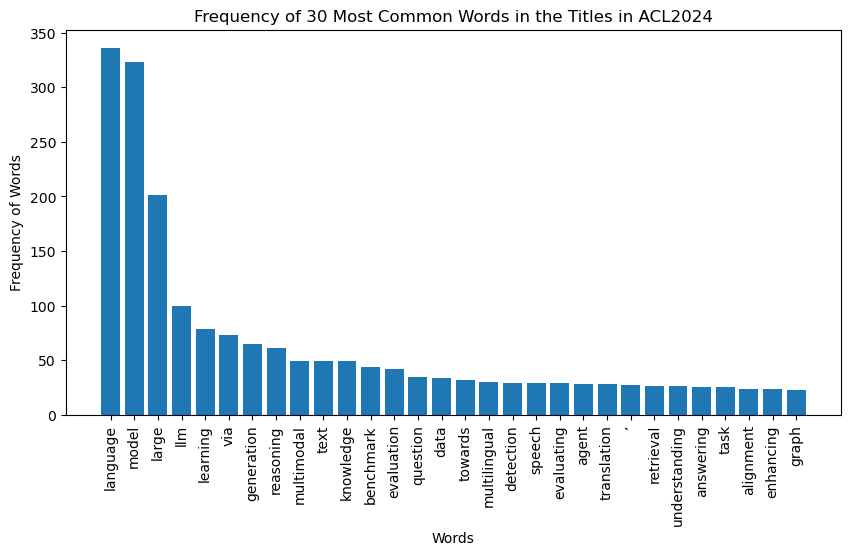

In [26]:
import matplotlib.pyplot as plt

x, y = zip(*fdist.most_common(30))

plt.figure(figsize=(10,5))
plt.bar(x, y)
plt.xlabel('Words')
plt.ylabel('Frequency of Words')
plt.xticks(rotation=90)
plt.title('Frequency of 30 Most Common Words in the Titles in ACL2024')
plt.show()

## [Optional]: Text Classification Using Bag-of-Words

In this task you will train a bag-of-words text classifier without lemmatization and with lemmatization and compare the results.

In [27]:
%conda install scikit-learn spacy --y
!python -m spacy download en_core_web_sm

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.7 MB/s  0:00:00m0:00:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [28]:
from time import time

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer


categories = [
    "alt.atheism",
    "talk.religion.misc",
    "comp.graphics",
    "sci.space",
]


def size_mb(docs):
    return sum(len(s.encode("utf-8")) for s in docs) / 1e6


def load_dataset(remove=(), perform_lemmatization=False):
    """Load and vectorize the 20 newsgroups dataset."""

    ### This line may cause error related to zlib. If so, try to install zlib via conda install zlib --y
    data_train = fetch_20newsgroups(
        subset="train",
        categories=categories,
        shuffle=True,
        random_state=42,
        remove=remove,
    )

    data_train.data = data_train.data[:200]
    data_train.target = data_train.target[:200]

    data_test = fetch_20newsgroups(
        subset="test",
        categories=categories,
        shuffle=True,
        random_state=42,
        remove=remove,
    )

    data_test.data = data_test.data[:500]
    data_test.target = data_test.target[:500]

    if perform_lemmatization:
        # Here, we use spacy for lemmatization instead of nltk since it performs lemmatization taking into account the context.
        # This important as lemmatization might change depending on the context of the word. So spacy is a better choice.

        # Load spaCy's English language model 
        import spacy
        nlp = spacy.load("en_core_web_sm")

        def lemmatize_text(text):
            # Process the text with spaCy
            doc = nlp(text)
            # Lemmatize, remove stop words and punctuation
            lemmatized_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
            return ' '.join(lemmatized_tokens)
        
        data_train.data = [lemmatize_text(text) for text in data_train.data]
        data_test.data = [lemmatize_text(text) for text in data_test.data]  


    # order of labels in `target_names` can be different from `categories`
    target_names = data_train.target_names

    # split target in a training set and a test set
    y_train, y_test = data_train.target, data_test.target

    # Extracting features from the training data using a sparse vectorizer
    t0 = time()
    vectorizer = TfidfVectorizer(
        sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english", use_idf=True
    )
    X_train = vectorizer.fit_transform(data_train.data)
    duration_train = time() - t0

    # Extracting features from the test data using the same vectorizer
    t0 = time()
    X_test = vectorizer.transform(data_test.data)
    duration_test = time() - t0

    feature_names = vectorizer.get_feature_names_out()

    # compute size of loaded data
    data_train_size_mb = size_mb(data_train.data)
    data_test_size_mb = size_mb(data_test.data)

    print(
        f"{len(data_train.data)} documents - "
        f"{data_train_size_mb:.2f}MB (training set)"
    )
    print(f"{len(data_test.data)} documents - {data_test_size_mb:.2f}MB (test set)")
    print(f"{len(target_names)} categories")
    print(
        f"vectorize training done in {duration_train:.3f}s "
        f"at {data_train_size_mb / duration_train:.3f}MB/s"
    )
    print(f"n_samples: {X_train.shape[0]}, n_features: {X_train.shape[1]}")
    print(
        f"vectorize testing done in {duration_test:.3f}s "
        f"at {data_test_size_mb / duration_test:.3f}MB/s"
    )
    print(f"n_samples: {X_test.shape[0]}, n_features: {X_test.shape[1]}")

    return X_train, X_test, y_train, y_test, feature_names, target_names

TASK: train and evaluate a text classifier with perform_lemmatization=False, remember its performance. Then change perform_lemmatization=True ,train and evaluate the classifier again. How does the performance change after adding lemmatization?

In [29]:
X_train, X_test, y_train, y_test, feature_names, target_names = load_dataset(perform_lemmatization=False)

200 documents - 0.42MB (training set)
500 documents - 1.18MB (test set)
4 categories
vectorize training done in 0.017s at 24.473MB/s
n_samples: 200, n_features: 1085
vectorize testing done in 0.034s at 34.823MB/s
n_samples: 500, n_features: 1085


In [30]:
from sklearn.linear_model import RidgeClassifier

clf = RidgeClassifier(tol=1e-2, solver="sparse_cg")
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

F1-macro: 0.7603592054853773


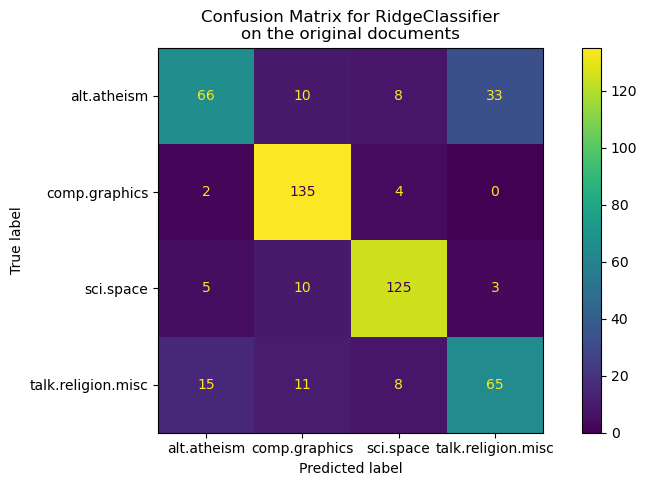

In [31]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, f1_score

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax)
ax.xaxis.set_ticklabels(target_names)
ax.yaxis.set_ticklabels(target_names)
_ = ax.set_title(
    f"Confusion Matrix for {clf.__class__.__name__}\non the original documents"
)

print("F1-macro:", f1_score(y_test, pred, average="macro"))

In [32]:
X_train, X_test, y_train, y_test, feature_names, target_names = load_dataset(perform_lemmatization=True)

200 documents - 0.30MB (training set)
500 documents - 0.82MB (test set)
4 categories
vectorize training done in 0.013s at 22.300MB/s
n_samples: 200, n_features: 1053
vectorize testing done in 0.024s at 33.549MB/s
n_samples: 500, n_features: 1053


In [33]:
from sklearn.linear_model import RidgeClassifier

clf = RidgeClassifier(tol=1e-2, solver="sparse_cg")
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

F1-macro: 0.7782193988858592


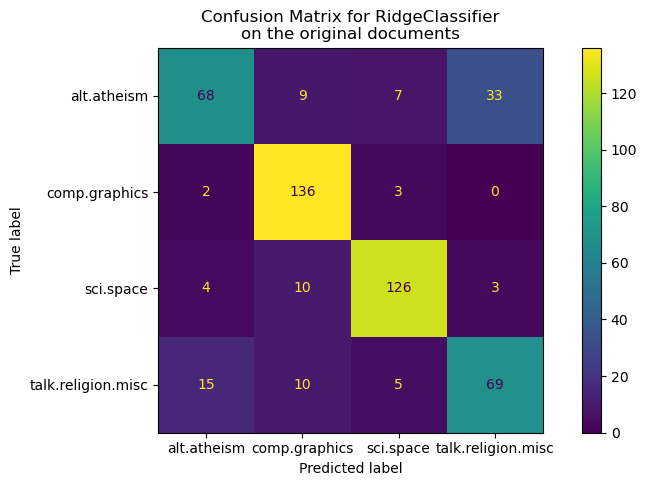

In [34]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay, f1_score

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax)
ax.xaxis.set_ticklabels(target_names)
ax.yaxis.set_ticklabels(target_names)
_ = ax.set_title(
    f"Confusion Matrix for {clf.__class__.__name__}\non the original documents"
)

print("F1-macro:", f1_score(y_test, pred, average="macro"))

--> After adding lemmatization, the performance when up a bit

# 2. N-grams Language Models (N-grams LM)

Nowadays, everything seems to be going neural... 

N-grams are continuous sequences of words or symbols or tokens in a document. In technical terms, they can be defined as the neighbouring sequences of items in a document. They come into play when we deal with text data in NLP(Natural Language Processing) tasks.

Traditionally, we can use n-grams to generate language models to predict which word comes next given a history of words. 

We'll use the `lm` module in `nltk` to get a sense of how non-neural language modelling is done.

## Unigram, bigram and trigram

N-Grams are phrases cut out of a sentence with N consecutive words. Thus a Unigram takes a sentence and gives us all the words in that we fence. A Bigram takes a sentence and gives us sets of two consecutive words in the sentence. A Trigram gives sets of threee consecutive words in a sentence.

Let me explain with an example.

Unigram - [Let] [me] [explain] [with] [an] [example.]

Bigram [let me] [me explain] [explain with] [with an] [an example]

Trigram [let me explain] [me explain with] [explain with an] [with an example]

Hope it explains.

In [35]:
# !conda install -U pip
%conda install -U dill --y
%conda install -U nltk==3.4 --y

usage: conda [-h] [-v] [--no-plugins] [-V] COMMAND ...
conda: error: unrecognized arguments: -U

Note: you may need to restart the kernel to use updated packages.
usage: conda [-h] [-v] [--no-plugins] [-V] COMMAND ...
conda: error: unrecognized arguments: -U

Note: you may need to restart the kernel to use updated packages.


In [36]:
from nltk.util import pad_sequence
from nltk.util import bigrams
from nltk.util import ngrams
from nltk.util import everygrams
from nltk.lm.preprocessing import pad_both_ends
from nltk.lm.preprocessing import flatten

If we want to train a bigram model, we need to turn this text into bigrams. Here's what the first sentence of our text would look like if we use the `ngrams` function from NLTK for this.

In [37]:
text = [['a', 'b', 'c'], ['a', 'c', 'd', 'c', 'e', 'f']]

In [38]:
list(bigrams(text[0]))

[('a', 'b'), ('b', 'c')]

Notice how "b" occurs both as the first and second member of different bigrams but "a" and "c" don't? 

--> yes

In [39]:
list(ngrams(text[1], n=3))

[('a', 'c', 'd'), ('c', 'd', 'c'), ('d', 'c', 'e'), ('c', 'e', 'f')]



Wouldn't it be nice to somehow indicate how often sentences start with "a" and end with "c"?


A standard way to deal with this is to add special "padding" symbols to the sentence before splitting it into ngrams. Fortunately, NLTK also has a function for that, let's see what it does to the first sentence.


In [40]:
from nltk.util import pad_sequence
list(pad_sequence(text[0],
                  pad_left=True, left_pad_symbol="<s>",
                  pad_right=True, right_pad_symbol="</s>",
                  n=2)) # The n order of n-grams, if it's 2-grams, you pad once, 3-grams pad twice, etc. 

['<s>', 'a', 'b', 'c', '</s>']

In [41]:
padded_sent = list(pad_sequence(text[0], pad_left=True, left_pad_symbol="<s>", 
                                pad_right=True, right_pad_symbol="</s>", n=2))
list(ngrams(padded_sent, n=2))

[('<s>', 'a'), ('a', 'b'), ('b', 'c'), ('c', '</s>')]

In [42]:
list(pad_sequence(text[0],
                  pad_left=True, left_pad_symbol="<s>",
                  pad_right=True, right_pad_symbol="</s>",
                  n=3)) # The n order of n-grams, if it's 2-grams, you pad once, 3-grams pad twice, etc. 

['<s>', '<s>', 'a', 'b', 'c', '</s>', '</s>']

In [43]:
padded_sent = list(pad_sequence(text[0], pad_left=True, left_pad_symbol="<s>", 
                                pad_right=True, right_pad_symbol="</s>", n=3))
list(ngrams(padded_sent, n=3))

[('<s>', '<s>', 'a'),
 ('<s>', 'a', 'b'),
 ('a', 'b', 'c'),
 ('b', 'c', '</s>'),
 ('c', '</s>', '</s>')]

Note the `n` argument, that tells the function we need padding for bigrams.

Now, passing all these parameters every time is tedious and in most cases they can be safely assumed as defaults anyway.

Thus the `nltk.lm` module provides a convenience function that has all these arguments already set while the other arguments remain the same as for `pad_sequence`.

In [44]:
from nltk.lm.preprocessing import pad_both_ends
list(pad_both_ends(text[0], n=2))

['<s>', 'a', 'b', 'c', '</s>']

Combining the two parts discussed so far we get the following preparation steps for one sentence.

In [45]:
list(bigrams(pad_both_ends(text[0], n=2)))

[('<s>', 'a'), ('a', 'b'), ('b', 'c'), ('c', '</s>')]

To make our model more robust we could also train it on unigrams (single words) as well as bigrams, its main source of information.
NLTK once again helpfully provides a function called `everygrams`.

While not the most efficient, it is conceptually simple.

In [46]:
from nltk.util import everygrams
padded_bigrams = list(pad_both_ends(text[0], n=2))
list(everygrams(padded_bigrams, max_len=2))

[('<s>',),
 ('<s>', 'a'),
 ('a',),
 ('a', 'b'),
 ('b',),
 ('b', 'c'),
 ('c',),
 ('c', '</s>'),
 ('</s>',)]

We are almost ready to start counting ngrams, just one more step left.

During training and evaluation our model will rely on a vocabulary that defines which words are "known" to the model.

To create this vocabulary we need to pad our sentences (just like for counting ngrams) and then combine the sentences into one flat stream of words.


In [47]:
from nltk.lm.preprocessing import flatten
list(flatten(pad_both_ends(sent, n=2) for sent in text))

['<s>', 'a', 'b', 'c', '</s>', '<s>', 'a', 'c', 'd', 'c', 'e', 'f', '</s>']

In most cases we want to use the same text as the source for both vocabulary and ngram counts.

Now that we understand what this means for our preprocessing, we can simply import a function that does everything for us.

In [48]:
from nltk.lm.preprocessing import padded_everygram_pipeline
train, vocab = padded_everygram_pipeline(2, text)

So as to avoid re-creating the text in memory, both `train` and `vocab` are lazy iterators. They are evaluated on demand at training time.

For the sake of understanding the output of `padded_everygram_pipeline`, we'll "materialize" the lazy iterators by casting them into a list.

In [49]:
training_ngrams, padded_sentences = padded_everygram_pipeline(2, text)
for ngramlize_sent in training_ngrams:
    print(list(ngramlize_sent))
    print()
print('#############')
list(padded_sentences)

[('<s>',), ('<s>', 'a'), ('a',), ('a', 'b'), ('b',), ('b', 'c'), ('c',), ('c', '</s>'), ('</s>',)]

[('<s>',), ('<s>', 'a'), ('a',), ('a', 'c'), ('c',), ('c', 'd'), ('d',), ('d', 'c'), ('c',), ('c', 'e'), ('e',), ('e', 'f'), ('f',), ('f', '</s>'), ('</s>',)]

#############


['<s>', 'a', 'b', 'c', '</s>', '<s>', 'a', 'c', 'd', 'c', 'e', 'f', '</s>']

## Lets get some real data and tokenize it

In [50]:
try: # Use the default NLTK tokenizer.
    from nltk import word_tokenize, sent_tokenize 
    # Testing whether it works. 
    # Sometimes it doesn't work on some machines because of setup issues.
    word_tokenize(sent_tokenize("This is a foobar sentence. Yes it is.")[0])
except: # Use a naive sentence tokenizer and toktok.
    import re
    from nltk.tokenize import ToktokTokenizer
    # See https://stackoverflow.com/a/25736515/610569
    sent_tokenize = lambda x: re.split(r'(?<=[^A-Z].[.?]) +(?=[A-Z])', x)
    # Use the toktok tokenizer that requires no dependencies.
    toktok = ToktokTokenizer()
    word_tokenize = word_tokenize = toktok.tokenize

In [51]:
import os
import requests
import io #codecs


# Text version of https://kilgarriff.co.uk/Publications/2005-K-lineer.pdf
if os.path.isfile('language-never-random.txt'):
    with io.open('language-never-random.txt', encoding='utf8') as fin:
        text = fin.read()
else:
    url = "https://gist.githubusercontent.com/alvations/53b01e4076573fea47c6057120bb017a/raw/b01ff96a5f76848450e648f35da6497ca9454e4a/language-never-random.txt"
    text = requests.get(url).content.decode('utf8')
    with io.open('language-never-random.txt', 'w', encoding='utf8') as fout:
        fout.write(text)

In [52]:
# Tokenize the text.
tokenized_text = [list(map(str.lower, word_tokenize(sent))) 
                  for sent in sent_tokenize(text)]

In [53]:
print(text[:500])

                       Language is never, ever, ever, random

                                                               ADAM KILGARRIFF




Abstract
Language users never choose words randomly, and language is essentially
non-random. Statistical hypothesis testing uses a null hypothesis, which
posits randomness. Hence, when we look at linguistic phenomena in cor-
pora, the null hypothesis will never be true. Moreover, where there is enough
data, we shall (almost) always be able to establish 


In [54]:
# Preprocess the tokenized text for 3-grams language modelling
n = 3
train_data, padded_sents = padded_everygram_pipeline(n, tokenized_text)

## Training an N-gram Model

Having prepared our data we are ready to start training a model. As a simple example, let us train a Maximum Likelihood Estimator (MLE).

We only need to specify the highest ngram order to instantiate it.

In [55]:
from nltk.lm import MLE
model = MLE(n) # Lets train a 3-grams model, previously we set n=3

Initializing the MLE model, creates an empty vocabulary

In [56]:
len(model.vocab)

0

... which gets filled as we fit the model.

In [57]:
model.fit(train_data, padded_sents)
print(model.vocab)

<Vocabulary with cutoff=1 unk_label='<UNK>' and 1391 items>


In [58]:
len(model.vocab)

1391

The vocabulary helps us handle words that have not occurred during training.

In [59]:
print(model.vocab.lookup(tokenized_text[0]))

('language', 'is', 'never', ',', 'ever', ',', 'ever', ',', 'random', 'adam', 'kilgarriff', 'abstract', 'language', 'users', 'never', 'choose', 'words', 'randomly', ',', 'and', 'language', 'is', 'essentially', 'non-random', '.')


In [60]:
# If we lookup the vocab on unseen sentences not from the training data, 
# it automatically replace words not in the vocabulary with `<UNK>`.
print(model.vocab.lookup('language is never random lah .'.split()))

('language', 'is', 'never', 'random', '<UNK>', '.')


Moreover, in some cases we want to ignore words that we did see during training but that didn't occur frequently enough, to provide us useful information. 

You can tell the vocabulary to ignore such words using the `unk_cutoff` argument for the vocabulary lookup, To find out how that works, check out the docs for the [`nltk.lm.vocabulary.Vocabulary` class](https://github.com/nltk/nltk/blob/develop/nltk/lm/vocabulary.py)

**Note:** For more sophisticated ngram models, take a look at [these objects from `nltk.lm.models`](https://github.com/nltk/nltk/blob/develop/nltk/lm/models.py):

 - `Lidstone`: Provides Lidstone-smoothed scores.
 - `Laplace`: Implements Laplace (add one) smoothing.
 - `InterpolatedLanguageModel`: Logic common to all interpolated language models (Chen & Goodman 1995).
 - `WittenBellInterpolated`: Interpolated version of Witten-Bell smoothing.

## Using the N-gram Language Model

When it comes to ngram models the training boils down to counting up the ngrams from the training corpus.

In [61]:
print(model.counts)

<NgramCounter with 3 ngram orders and 19611 ngrams>


This provides a convenient interface to access counts for unigrams...

In [62]:
model.counts['language'] # i.e. Count('language')

25

...and bigrams for the phrase "language is"

In [63]:
model.counts[['language']]['is'] # i.e. Count('is'|'language')

11

... and trigrams for the phrase "language is never"

In [64]:
model.counts[['language', 'is']]['never'] # i.e. Count('never'|'language is')

7

And so on. However, the real purpose of training a language model is to have it score how probable words are in certain contexts.

This being MLE, the model returns the item's relative frequency as its score.

In [65]:
model.score('language') # P('language')

0.003691671588895452

In [66]:
model.score('is', 'language'.split())  # P('is'|'language')

0.44

In [67]:
model.score('never', 'language is'.split())  # P('never'|'language is')

0.6363636363636364

Items that are not seen during training are mapped to the vocabulary's "unknown label" token.  This is "<UNK>" by default.


In [68]:
model.score("<UNK>") == model.score("lah")

True

In [69]:
model.score("<UNK>") == model.score("leh")

True

In [70]:
model.score("<UNK>") == model.score("lor")

True

To avoid underflow when working with many small score values it makes sense to take their logarithm. 

For convenience this can be done with the `logscore` method.


In [71]:
model.logscore("never", "language is".split())

-0.6520766965796932

## Perplexity

We can also use language models to compute the perplexity to some input text. 

In [72]:
test_text = "However, it is not in general possible to model the A-M distinction mathematically. I like apple juice."

tokenized_test_text = [list(map(str.lower, word_tokenize(sent))) 
                  for sent in sent_tokenize(test_text)]
test_data, padded_test_sents = padded_everygram_pipeline(n, tokenized_test_text)
for test in test_data:
    print("per", model.perplexity(test))


per 14.253053274168975
per inf


What does an infinite perplexity mean? How to get a more meaningful perplexity value? How would smoothing help?

--> Infinite perplexity signals that your model has encountered something it thinks is impossible (probability zero), which makes it "infinitely surprised".

- To get a more meaningful perplexity, the goal is to avoid assigning zero probability to words/events that could occur in the test set. We can use smoothing techniques (Laplace, Add-k, Good-Turing, Kneser-Ney, etc.), backoff or interpolation with lower-order models (e.g., fall back from trigrams → bigrams → unigrams if unseen), or even use neural models (RNNs, Transformers), as they typically don’t assign exact zero probability (since they produce probabilities through softmax, but they can still assign extremely small values).

- Smoothing redistributes some probability mass from seen events to unseen ones. For example, Laplace smoothing adds a small constant (e.g., +1) to all counts, ensures that unseen words/events get a small, nonzero probability instead of zero. As a result, the model never outputs probability = 0, negative log-likelihood is finite, and perplexity is meaningful and comparable across models.

## Generation using N-gram Language Model

One cool feature of ngram models is that they can be used to generate text.

In [73]:
print(model.generate(20, random_seed=7))

['and', 'carroll', 'used', 'hypothesis', 'testing', 'has', 'been', 'used', ',', 'and', 'a', 'half', '.', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>']


We can do some cleaning to the generated tokens to make it human-like.

In [74]:
from nltk.tokenize.treebank import TreebankWordDetokenizer

detokenize = TreebankWordDetokenizer().detokenize

def generate_sent(model, num_words, random_seed=42):
    """
    :param model: An ngram language model from `nltk.lm.model`.
    :param num_words: Max no. of words to generate.
    :param random_seed: Seed value for random.
    """
    content = []
    for token in model.generate(num_words, random_seed=random_seed):
        if token == '<s>':
            continue
        if token == '</s>':
            break
        content.append(token)
    return detokenize(content)

In [75]:
generate_sent(model, 20, random_seed=7)

'and carroll used hypothesis testing has been used, and a half.'

In [76]:
print(model.generate(28, random_seed=0))

['the', 'scf-verb', 'link', 'is', 'motivated', '.', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>', '</s>']


In [77]:
generate_sent(model, 28, random_seed=0)

'the scf-verb link is motivated.'

In [78]:
generate_sent(model, 20, random_seed=1)

'237⫺246.'

In [79]:
generate_sent(model, 20, random_seed=30)

'hypothesis is ever a useful construct.'

In [80]:
generate_sent(model, 20, random_seed=42)

'more (or cold) weather, or on saturday nights, or by people in (or poorer)'

## Saving the model 

The native Python's pickle may not save the lambda functions in the  model, so we can use the `dill` library in place of pickle to save and load the language model.


In [81]:
%conda install dill --y

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/khang.nhat/anaconda3/envs/nlplab

  added / updated specs:
    - dill


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    dill-0.4.0                 |  py311h06a4308_0         232 KB
    ------------------------------------------------------------
                                           Total:         232 KB

The following NEW packages will be INSTALLED:

  dill               pkgs/main/linux-64::dill-0.4.0-py311h06a4308_0 



                                                                                
Preparing transaction: done
Verifying transacti

In [82]:
import dill as pickle 

with open('kilgariff_ngram_model.pkl', 'wb') as fout:
    pickle.dump(model, fout)

In [83]:
with open('kilgariff_ngram_model.pkl', 'rb') as fin:
    model_loaded = pickle.load(fin)

In [84]:
generate_sent(model_loaded, 20, random_seed=42)

'more (or cold) weather, or on saturday nights, or by people in (or poorer)'

## Lets try some generating with Donald Trump data!!!


**Dataset:** https://www.kaggle.com/kingburrito666/better-donald-trump-tweets#Donald-Tweets!.csv


In this part, I'll be munging that data as how I would be doing it at work. 
I've really no seen the data before but I hope this session would be helpful for you to see how to approach new datasets with the skills you have.

In [85]:
%conda install pandas --y

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/khang.nhat/anaconda3/envs/nlplab

  added / updated specs:
    - pandas


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    pandas-3.0.1               |  py311h86c3e14_0        14.2 MB
    ------------------------------------------------------------
                                           Total:        14.2 MB

The following NEW packages will be INSTALLED:

  pandas             pkgs/main/linux-64::pandas-3.0.1-py311h86c3e14_0 



                                                                                
Preparing transaction: done
Verifying trans

Dataset download source: https://www.kaggle.com/datasets/codebreaker619/donald-trump-tweets-dataset?resource=download


In [87]:
import pandas as pd

df = pd.read_csv('tweets.csv')
df.head()

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f


In [88]:
trump_corpus = list(df['text'].apply(word_tokenize))

In [89]:
# Preprocess the tokenized text for 3-grams language modelling
n = 3
train_data, padded_sents = padded_everygram_pipeline(n, trump_corpus)

In [90]:
from nltk.lm import MLE
trump_model = MLE(n) # Lets train a 3-grams model, previously we set n=3
trump_model.fit(train_data, padded_sents)

In [91]:
generate_sent(trump_model, num_words=20, random_seed=42)

'dropping" "" Good luck to @ NYCParks on quickly repairing the Lasker Rink . Record crowd in.'

In [92]:
generate_sent(trump_model, num_words=10, random_seed=0)

'run for office, hopefully in 6 seconds thanks to'

In [93]:
generate_sent(trump_model, num_words=50, random_seed=10)

"and got his ass kicked last night.He's afraid to go until it comes to our Southern Border Security . The good news is this what our Country!"

In [94]:
print(generate_sent(trump_model, num_words=100, random_seed=52))

years! Cruz dirty tricks . https: //t…


## [Optional] Compare the results to GPT-4o-mini

In [95]:
%conda install openai --y

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64

done
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/khang.nhat/anaconda3/envs/nlplab

  added / updated specs:
    - openai


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    anyio-4.12.1               |  py311h06a4308_0         304 KB
    distro-1.9.0               |  py311h06a4308_0          36 KB
    h11-0.16.0                 |  py311h06a4308_1          64 KB
    httpcore-1.0.9             |  py311h06a4308_0         121 KB
    httpx-0.28.1               |  py311h06a4308_1         212 KB
    jiter-0.12.0               |  py311h498d7c9_0         300 KB
    openai-2.14.0              |  py311h06a4308_0        1006 KB
    sniffio-1.3.1              |  py311h06a4308_0         

In [ ]:
from openai import OpenAI


client = OpenAI(api_key="")

completion = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {
            "role": "user",
            "content": "Write me a Tweet of Donald Trump about the US border."
        }
    ],
    max_tokens=250
)

print(completion.choices[0].message.content)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-nL4Tm***********************************************************************************9fkA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}